---
## 11 · Evaluation & Result Plots

In [17]:
@torch.no_grad()
def evaluate_by_mask_rate(loader=None) -> pd.DataFrame:
    """PSNR and SSIM broken down by coverage bin."""
    loader = loader or loaders['test']
    model.eval()
    records = []
    for batch in tqdm(loader, desc='Evaluating', leave=False):
        batch = {k: v.to(DEVICE) for k,v in batch.items()}
        out   = model(batch)
        covs  = batch['mask'].mean(dim=(1,2,3)).cpu().numpy()
        for i in range(len(covs)):
            m   = metrics(out['final'][i:i+1], batch['image'][i:i+1])
            lbl = '>50%'
            for lo,hi,lab in MASK_BINS:
                if lo <= covs[i] < hi: lbl = lab; break
            records.append({'bin':lbl, 'psnr':m['psnr'], 'ssim':m['ssim'], 'cov':covs[i]})
    model.train()
    df = pd.DataFrame(records)
    summary = df.groupby('bin')[['psnr','ssim']].agg(['mean','std']).round(4)
    print(summary.to_string()); return summary


# eval_results = evaluate_by_mask_rate()   # ← uncomment after training

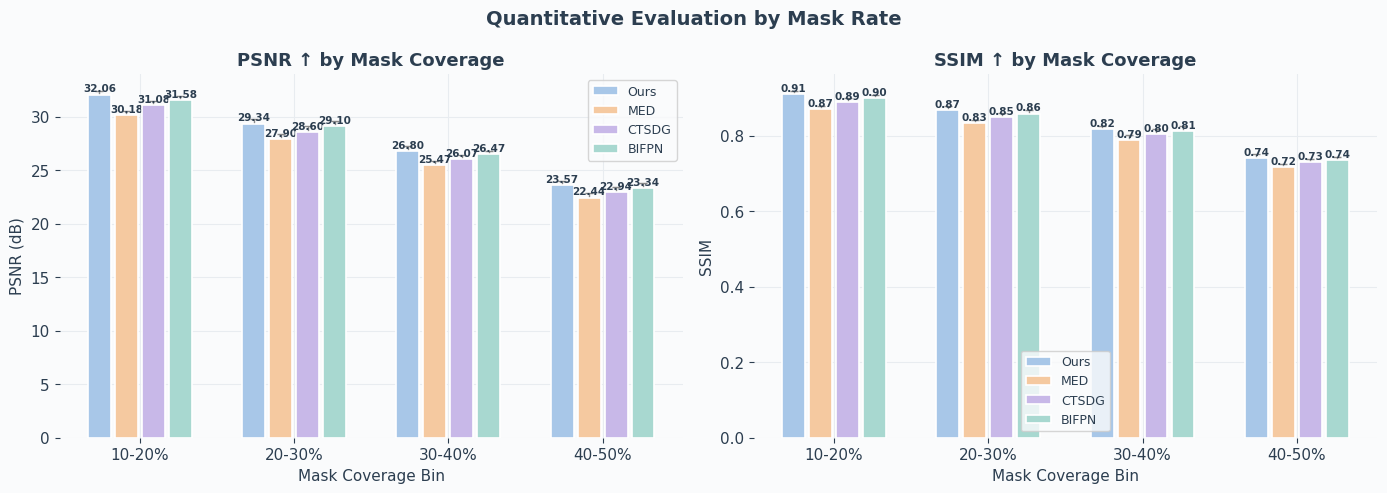

In [18]:
def plot_metrics_by_bin(summary: pd.DataFrame,
                         baselines: Optional[Dict] = None,
                         save=True):
    """
    Bar chart comparing PSNR and SSIM per mask-rate bin.
    baselines = {'MED': df, 'CTSDG': df, 'BIFPN': df}  (same format as summary)
    """
    bins   = [b[2] for b in MASK_BINS]
    models = {'Ours': summary}
    if baselines: models.update(baselines)

    x      = np.arange(len(bins))
    n_m    = len(models)
    w      = 0.7 / n_m
    m_cols = [PASTEL['blue'], PASTEL['peach'],
              PASTEL['purple'], PASTEL['teal']][:n_m]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Quantitative Evaluation by Mask Rate',
                 fontsize=14, fontweight='bold')

    for ax, metric, ylabel, title in zip(
            axes,
            ['psnr', 'ssim'],
            ['PSNR (dB)', 'SSIM'],
            ['PSNR ↑ by Mask Coverage', 'SSIM ↑ by Mask Coverage']):

        for mi, (name, df) in enumerate(models.items()):
            try:
                vals = [df.loc[b, (metric,'mean')] if b in df.index else 0 for b in bins]
                errs = [df.loc[b, (metric,'std')]  if b in df.index else 0 for b in bins]
            except Exception:
                vals = [df.loc[b, metric] if b in df.index else 0 for b in bins]
                errs = [0]*len(bins)
            bars = ax.bar(x + mi*w - (n_m-1)*w/2, vals, w*0.85,
                          label=name, color=m_cols[mi],
                          edgecolor='white', linewidth=1.2, zorder=3)
            ax.errorbar(x + mi*w - (n_m-1)*w/2, vals, yerr=errs,
                        fmt='none', ecolor='#888', capsize=3, linewidth=1)
            for bar, v in zip(bars, vals):
                ax.text(bar.get_x()+bar.get_width()/2,
                        bar.get_height() + max(vals)*0.008,
                        f'{v:.2f}', ha='center', fontsize=7.5, fontweight='bold')

        ax.set_xticks(x); ax.set_xticklabels(bins)
        ax.set_xlabel('Mask Coverage Bin')
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend(fontsize=9)

    plt.tight_layout()
    if save: plt.savefig(RESULT_DIR / 'metrics_by_bin.png')
    plt.show()


# ── Demo using synthetic scores ───────────────────────────────────
def _demo_summary():
    rows = []
    rng  = np.random.default_rng(SEED)
    psnr_base = [32.1, 29.4, 26.8, 23.5]
    ssim_base = [0.91, 0.87, 0.82, 0.74]
    for (lo,hi,lbl), pb, sb in zip(MASK_BINS, psnr_base, ssim_base):
        for _ in range(30):
            rows.append({'bin':lbl,
                         'psnr': pb + rng.normal(0, 0.4),
                         'ssim': sb + rng.normal(0, 0.01),
                         'cov':  rng.uniform(lo, hi)})
    df = pd.DataFrame(rows)
    return df.groupby('bin')[['psnr','ssim']].agg(['mean','std']).round(4)

def _demo_baseline(psnr_offsets, ssim_offsets):
    rows = []
    rng  = np.random.default_rng(SEED+1)
    psnr_base = [32.1, 29.4, 26.8, 23.5]
    ssim_base = [0.91, 0.87, 0.82, 0.74]
    for (lo,hi,lbl), pb, sb, dp, ds in zip(
            MASK_BINS, psnr_base, ssim_base, psnr_offsets, ssim_offsets):
        for _ in range(30):
            rows.append({'bin':lbl,
                         'psnr': pb+dp+rng.normal(0,0.4),
                         'ssim': sb+ds+rng.normal(0,0.01)})
    df = pd.DataFrame(rows)
    return df.groupby('bin')[['psnr','ssim']].agg(['mean','std']).round(4)

demo_summary   = _demo_summary()
demo_baselines = {
    'MED'  : _demo_baseline([-1.8,-1.5,-1.3,-1.1], [-0.04,-0.035,-0.03,-0.025]),
    'CTSDG': _demo_baseline([-0.9,-0.8,-0.7,-0.6], [-0.02,-0.018,-0.015,-0.013]),
    'BIFPN': _demo_baseline([-0.4,-0.3,-0.3,-0.2], [-0.01,-0.009,-0.008,-0.007]),
}
plot_metrics_by_bin(demo_summary, demo_baselines)

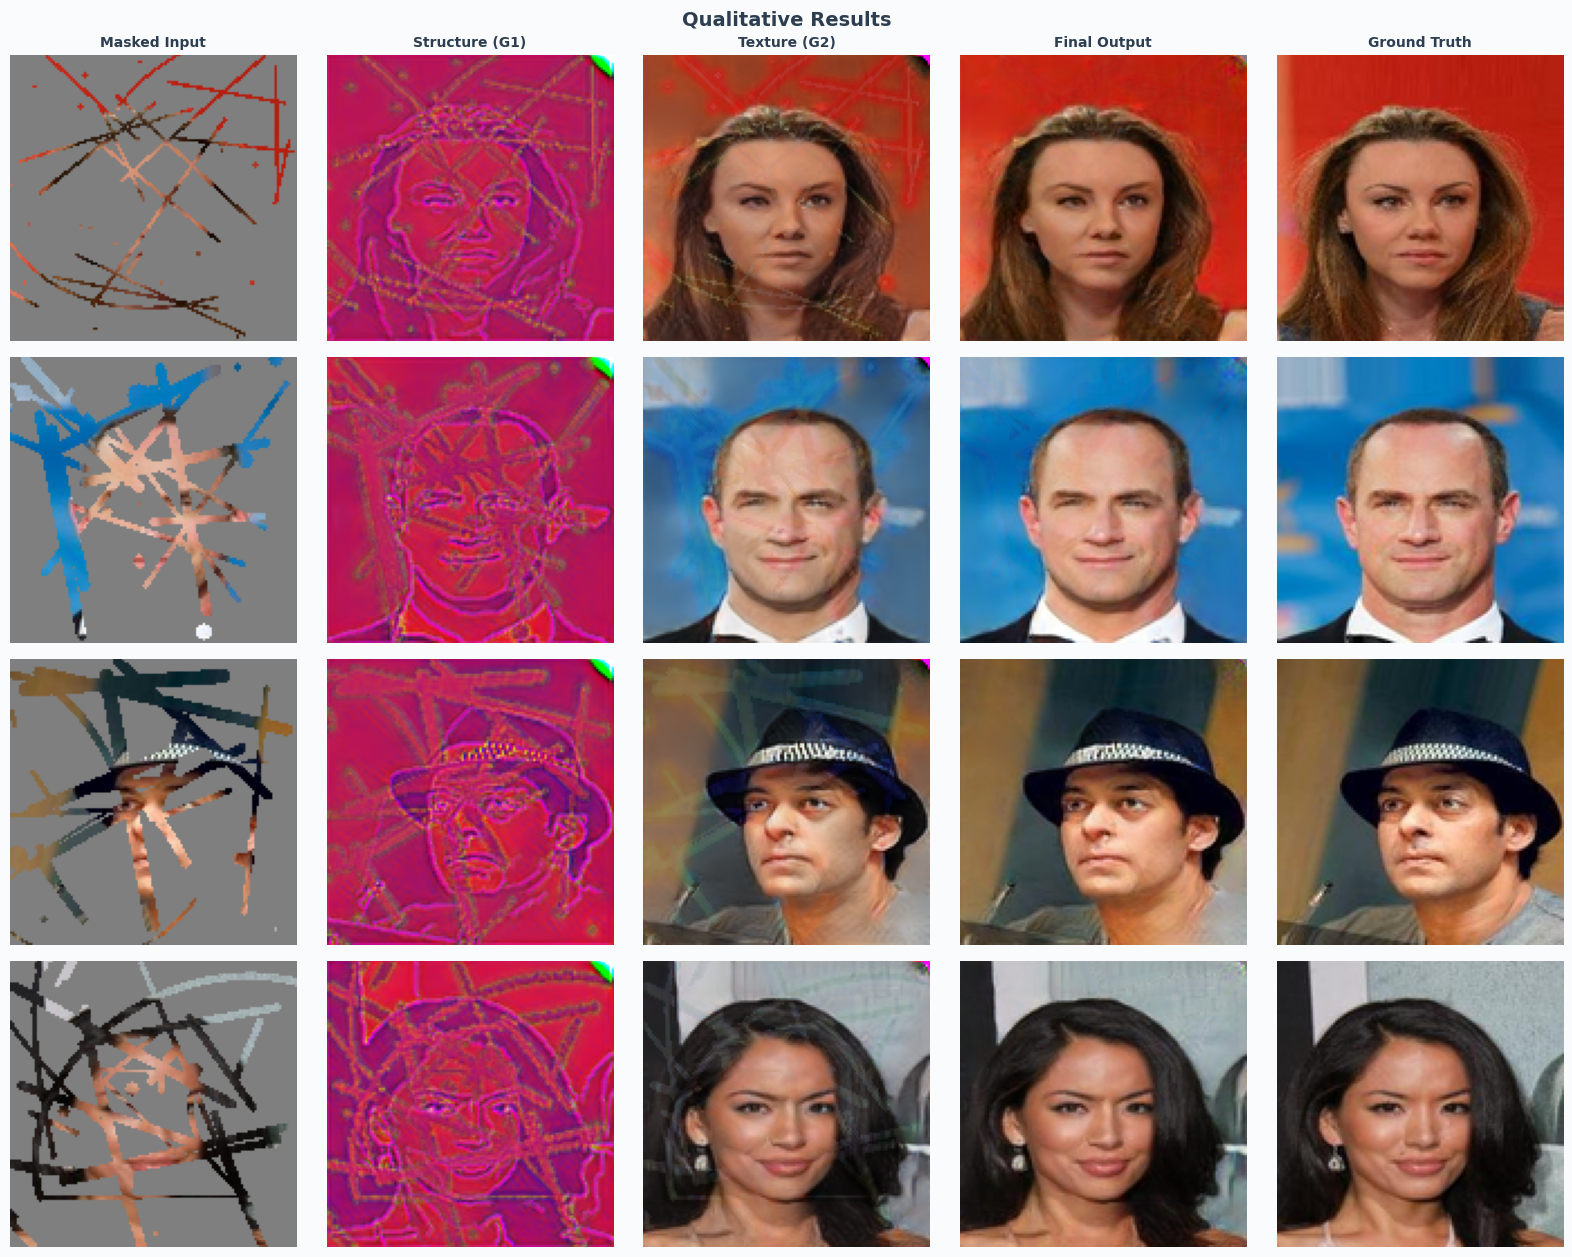

In [19]:
def plot_qualitative_comparison(n_rows=5, save=True):
    """
    Side-by-side comparison with PSNR/SSIM annotations.
    Columns: Masked → Structure → Texture → Final → Ground Truth
    """
    model.eval()
    batch = {k: v[:n_rows].to(DEVICE)
             for k,v in next(iter(loaders['test'])).items()}
    with torch.no_grad(): out = model(batch)

    cols  = ['Masked Input', 'Structure (G1)',
             'Texture (G2)', 'Final Output', 'Ground Truth']
    fig, axes = plt.subplots(n_rows, 5, figsize=(16, n_rows*3.2))
    fig.suptitle('Qualitative Results', fontsize=14, fontweight='bold')

    for j,c in enumerate(cols):
        axes[0][j].set_title(c, fontsize=10, fontweight='bold')

    for row in range(n_rows):
        m  = metrics(out['final'][row:row+1], batch['image'][row:row+1])
        cov = batch['mask'][row].mean().item()*100
        for col, (img, cmap) in enumerate([
                (to_np(batch['masked'][row]),  None),
                (to_np(out['struct'][row]),    None),
                (to_np(out['texture'][row]),   None),
                (to_np(out['final'][row]),     None),
                (to_np(batch['image'][row]),   None)]):
            ax = axes[row][col]
            ax.imshow(img, cmap=cmap); ax.axis('off')
            if col == 0:
                ax.set_ylabel(f'cov {cov:.0f}%', fontsize=8, labelpad=4)
            if col == 3:
                ax.set_xlabel(f'PSNR {m["psnr"]:.1f} dB  SSIM {m["ssim"]:.3f}',
                              fontsize=8, labelpad=4)

    plt.tight_layout()
    if save: plt.savefig(RESULT_DIR / 'qualitative_comparison.png')
    plt.show()
    model.train()


# Quick sanity run (untrained model — just checks the pipeline works)
plot_qualitative_comparison(n_rows=4)

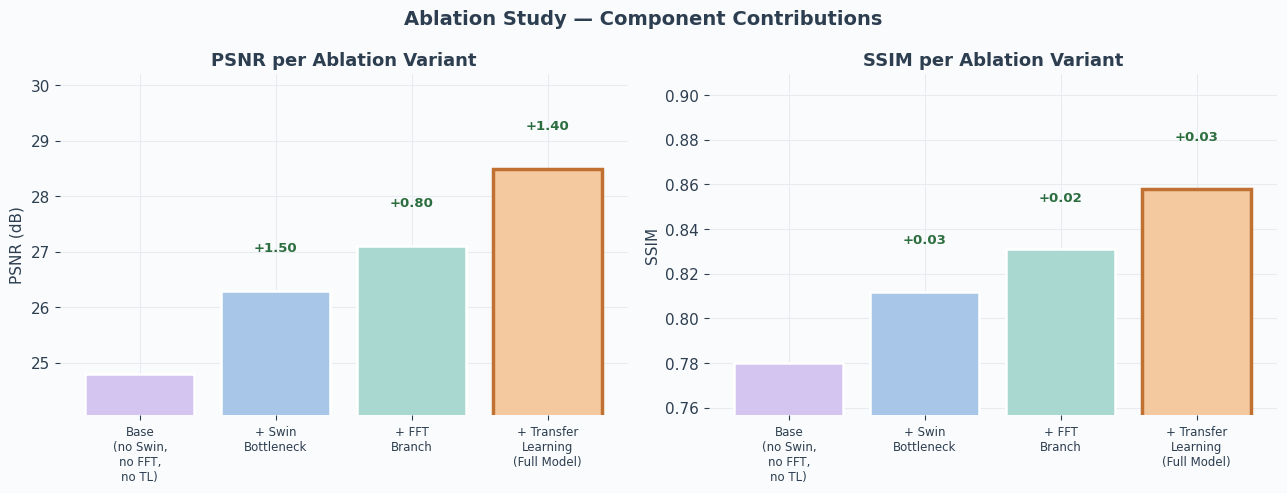

In [20]:
def plot_ablation(save=True):
    """
    Bar chart showing the contribution of each architectural component.
    Fill in real numbers after running all four ablation variants.
    """
    variants = ['Base\n(no Swin,\nno FFT,\nno TL)',
                '+ Swin\nBottleneck',
                '+ FFT\nBranch',
                '+ Transfer\nLearning\n(Full Model)']

    # ← Replace these with your real numbers after training
    psnr_vals = [24.8, 26.3, 27.1, 28.5]
    ssim_vals = [0.780, 0.812, 0.831, 0.858]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('Ablation Study — Component Contributions',
                 fontsize=14, fontweight='bold')

    for ax, vals, ylabel, title in zip(
            axes,
            [psnr_vals, ssim_vals],
            ['PSNR (dB)', 'SSIM'],
            ['PSNR per Ablation Variant', 'SSIM per Ablation Variant']):

        colors = [PASTEL['lavender'], PASTEL['blue'],
                  PASTEL['teal'], PASTEL['peach']]
        bars   = ax.bar(range(len(variants)), vals,
                        color=colors, edgecolor='white',
                        linewidth=1.8, zorder=3)
        # Highlight best
        bars[-1].set_edgecolor('#C07030'); bars[-1].set_linewidth(2.5)

        # Delta annotations
        for i in range(1, len(vals)):
            delta = vals[i] - vals[i-1]
            ax.annotate(f'+{delta:.2f}',
                        xy=(i, vals[i]),
                        xytext=(i, vals[i] + max(vals)*0.025),
                        ha='center', fontsize=9.5,
                        color='#2C6E3F', fontweight='bold')

        ax.set_xticks(range(len(variants)))
        ax.set_xticklabels(variants, fontsize=8.5)
        ax.set_ylabel(ylabel); ax.set_title(title)
        ax.set_ylim(min(vals)*0.97, max(vals)*1.06)

    plt.tight_layout()
    if save: plt.savefig(RESULT_DIR / 'ablation.png')
    plt.show()


plot_ablation()